<a href="https://colab.research.google.com/github/yumsj0626-afk/AI-Product-Management/blob/main/%EA%B3%B5%EC%9C%A0_%EC%9E%90%EC%A0%84%EA%B1%B0_%EC%88%98%EC%9A%94_%EC%98%88%EC%B8%A1_%EB%AA%A8%EB%8D%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 회귀 모델 실습: 수요 예측(자전거 대여량)

- **데이터셋**: Bike Sharing Dataset (`hour.csv`)
- **문제정의 (시나리오)**: 날짜/시간/날씨/계절 정보를 기반으로 시간대별 자전거 대여량(cnt)을 예측하는 회귀 모델을 구축

- **핵심 목표**
  1) 운영 인력/자전거 재배치 의사결정 지원
  >  - 어느 시간대에 수요가 폭증/감소하는가?”를 예측 기반으로 판단
  2) 각 특성별 결합 전처리 경험
  >  - 날짜 파생(hour/dayofweek/month)
  >  - 범주형 원핫(weathersit/season/weekday/hr)
  >  - 수치 스케일링(temp/hum/windspeed)
  3) 여러 회귀 모델 비교로 기준선 vs 개선 구조 학습
  >  - Baseline: LinearRegression
  >  - 규제: Ridge/Lasso
  >  - 비선형: DecisionTree/RandomForest
  >  - XGBRegressor: 환경 가능 시만
  
> **산출물**  
> - 모델별 **MAE/RMSE/R² 비교표**  
> - **Actual vs Predicted** 산점도  
> - 테스트 구간 일부 **라인 플롯(실제 vs 예측)**  
> - (가능하면) **중요 피처/계수** 간단 해석



##실습 환경 구성


In [2]:
import os
import zipfile
import urllib.request

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

RANDOM_STATE = 42

- UCI 데이터 공유 사이트의 경우 직접 데이터에 접근하여 받아올 수 있도록 지원하고 있음
- 따라서, 로컬 컴퓨터에 다운받을 데이터를 저장할 디렉토리를 설정하고 경로 정보까지 설정함
- URL 값을 통해 데이터를 다운로드 받고 압축파일을 풀어 데이터를 불러오기 위한 과정


In [18]:
# 데이터 준비 (이미 /content 에 파일이 있으므로 이를 활용)
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

# 현재 경로에 있는 파일을 DATA_DIR로 이동시키거나 바로 경로를 지정합니다.
hour_csv_path = "./hour.csv"

if os.path.exists(hour_csv_path):
    print(f"로컬에 있는 {hour_csv_path} 파일을 사용합니다.")
else:
    # 만약 파일이 없다면 기존 로직을 따르되, 우선 현재는 있는 파일을 쓰도록 설정
    print("파일을 찾을 수 없습니다. 경로를 확인해주세요.")

로컬에 있는 ./hour.csv 파일을 사용합니다.


## 1.데이터 로드 및 컬럼 확인하기
hour.csv 는 시간 단위 데이터 대여량을 담고 있음


In [19]:
### 정답

df = pd.read_csv(hour_csv_path)
display(df.head())
print(df.shape)
df.info()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


(17379, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## 2. 날짜/시간 파생 변수 만들기

날짜 컬럼에서 아래 같은 파생을 자주 만들기

- `hour` (시간대)
- `dayofweek` (요일)
- `month` (월)

이 데이터셋은 이미 `hr`, `weekday`, `mnth` 컬럼이 있음


In [20]:
### 정답

df = df.copy()

# 날짜 파싱
df["dteday"] = pd.to_datetime(df["dteday"])

# 파생 (원본 hr/weekday/mnth가 이미 있어도 '직접 만들어보기')
df["hour"] = df["hr"]
df["dayofweek_from_date"] = df["dteday"].dt.dayofweek  # 월=0 ... 일=6
df["month_from_date"] = df["dteday"].dt.month

# 원본과 간단 비교(일부 샘플)
display(df[["dteday", "hr", "weekday", "mnth", "dayofweek_from_date", "month_from_date"]].head(10))


,dteday,hr,weekday,mnth,dayofweek_from_date,month_from_date
0,2011-01-01,0,6,1,5,1
1,2011-01-01,1,6,1,5,1
2,2011-01-01,2,6,1,5,1
3,2011-01-01,3,6,1,5,1
4,2011-01-01,4,6,1,5,1
5,2011-01-01,5,6,1,5,1
6,2011-01-01,6,6,1,5,1
7,2011-01-01,7,6,1,5,1
8,2011-01-01,8,6,1,5,1
9,2011-01-01,9,6,1,5,1


## 3. Train/Test 분리 (데이터 누수 방지)

### 시간 기준 분리
- 수요 예측의 경우 미래를 예측하는 것이 중요하다고 판단함.
- 랜덤으로 데이터를 섞을 경우, 날짜의 순서가 달라지기 때문에 성능이 과대평가 될 수 있음
- 본 실습에서는 데이터를 랜덤으로 섞지 않고 진행
- 누수 컬럼을 삭제하고, 범주형과 수치형 컬럼을 선택하여 리스트에 저장
- 슬라이싱으로 train/test 데이터셋 분리
> - 앞 80%: train
> - 뒤 20%: test


In [21]:

# 시간 순서 정렬(날짜+시간)
df["datetime"] = df["dteday"] + pd.to_timedelta(df["hr"], unit="h")
df = df.sort_values("datetime").reset_index(drop=True)

# 누수 컬럼 제거(정답을 구성하는 정보)
leak_cols = ["casual", "registered"]
df = df.drop(columns=leak_cols)

target = "cnt"

# 학습/평가에 사용할 피처 목록(요구사항 반영)
# - 범주형: weathersit, season, weekday, hr (원핫)
# - 수치형: temp, hum, windspeed (스케일링)
# + 파생 예시: month_from_date, dayofweek_from_date
cat_features = ["weathersit", "season", "weekday", "hr"]
num_features = ["temp", "hum", "windspeed", "month_from_date", "dayofweek_from_date"]

feature_cols = cat_features + num_features

X = df[feature_cols]
y = df[target]

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train 기간:", df["datetime"].iloc[0], "~", df["datetime"].iloc[split_idx-1])
print("Test  기간:", df["datetime"].iloc[split_idx], "~", df["datetime"].iloc[-1])


Train: (13903, 9) Test: (3476, 9)
Train 기간: 2011-01-01 00:00:00 ~ 2012-08-07 11:00:00
Test  기간: 2012-08-07 12:00:00 ~ 2012-12-31 23:00:00


## 4. 전처리 파이프라인(원핫 + 스케일링)

- 범주형: `OneHotEncoder(handle_unknown="ignore")`
- 수치형: `StandardScaler()`


train에 맞춘 전처리가 test에 그대로 적용하여 **데이터 누수 방지**


In [13]:

# 전처리: 범주형(원-핫) + 수치형(스케일링)
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", StandardScaler(), num_features),
    ],
    remainder="drop",
)

preprocess


ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['weathersit', 'season', 'weekday', 'hr']),
                                ('num', StandardScaler(),
                                 ['temp', 'hum', 'windspeed', 'month_from_date',
                                  'dayofweek_from_date'])])

## 5. 모델 학습/평가 (비교 구조)
- 평가 지표를 함수로 선언하여 코드 효율화
- 반복문을 활용하여 정의한 모델에 순차적으로 학습 시킨 후 평가 지표를 계산함
- 최종 결과는 RMSE값이 가장 우수한 모델로 선정하여 출력

비교할 모델:
- **LinearRegression** (baseline)
- **Ridge / Lasso** (규제)
- **DecisionTree / RandomForest** (비선형)
- **XGBRegressor** (설치되어 있으면 선택 비교)

평가 지표:
- **MAE**
- **RMSE**
- **R²**


In [12]:
def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001, random_state=RANDOM_STATE, max_iter=5000),
    "DecisionTree": DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=None),
    "RandomForest": RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_estimators=300,
        n_jobs=-1,
        max_depth=None
    ),
}

if HAS_XGB:
    models["XGBRegressor"] = XGBRegressor(
        random_state=RANDOM_STATE,
        n_estimators=600,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="reg:squarederror",
        n_jobs=-1
    )

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    mae, rmse, r2 = evaluate_regression(y_test, pred)
    results.append({"model": name, "MAE": mae, "RMSE": rmse, "R2": r2})
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values("RMSE")
display(results_df)
best_name = results_df.iloc[0]["model"]
print("✅ Best model by RMSE:", best_name)

,model,MAE,RMSE,R2
5,XGBRegressor,89.447624,126.196449,0.672405
4,RandomForest,87.315831,126.495648,0.670850
3,DecisionTree,94.901467,139.690722,0.598600
0,LinearRegression,110.323052,158.466136,0.483446
2,Lasso,110.324148,158.472866,0.483402
1,Ridge,110.334033,158.522147,0.483081


✅ Best model by RMSE: XGBRegressor


## 6. 회귀 결과 해석 시각화

### (1) Actual vs Predicted 산점도


### (2) 테스트 일부 구간 라인 플롯
- 테스트 일부 구간 라인 플롯 시각화(첫 200개 데이터)
> - 실제값/예측값의 추세를 보기 위함
> - 시간의 흐름에 따라 비슷한지 확인



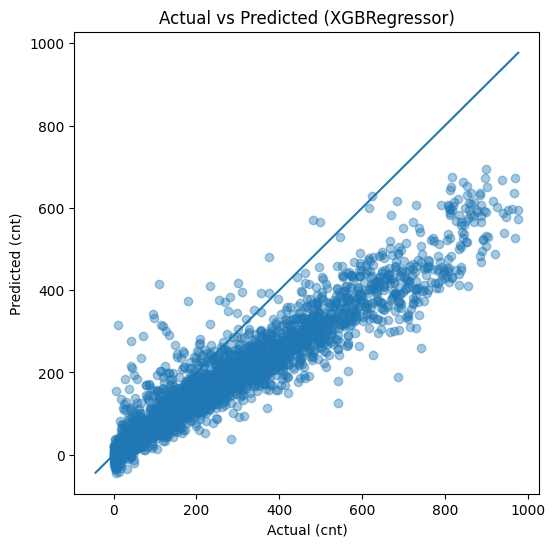

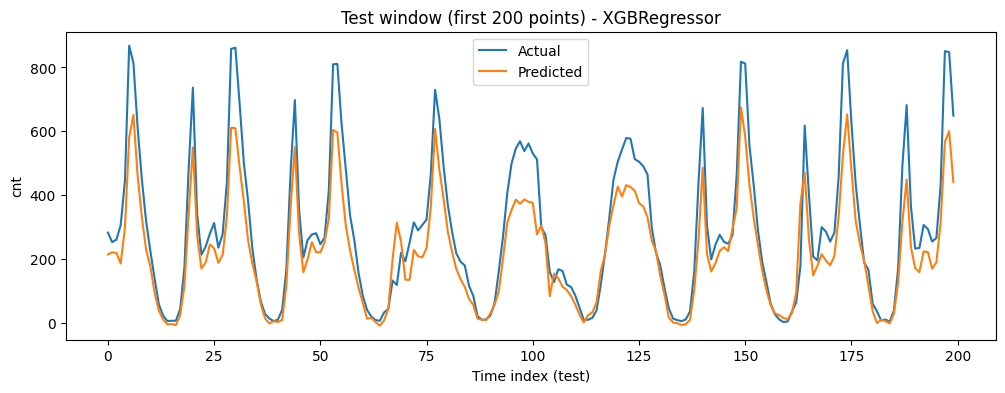

In [15]:

best_pipe = fitted_pipelines[best_name]
y_pred_best = best_pipe.predict(X_test)

# 1) Actual vs Predicted 산점도
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.4)
min_v = min(y_test.min(), y_pred_best.min())
max_v = max(y_test.max(), y_pred_best.max())
plt.plot([min_v, max_v], [min_v, max_v])
plt.title(f"Actual vs Predicted ({best_name})")
plt.xlabel("Actual (cnt)")
plt.ylabel("Predicted (cnt)")
plt.show()

# 2) 테스트 일부 구간 라인 플롯 (예: 처음 200개)
n_show = 200
idx = np.arange(min(n_show, len(y_test)))

plt.figure(figsize=(12, 4))
plt.plot(idx, y_test.iloc[:len(idx)].values, label="Actual")
plt.plot(idx, y_pred_best[:len(idx)], label="Predicted")
plt.title(f"Test window (first {len(idx)} points) - {best_name}")
plt.xlabel("Time index (test)")
plt.ylabel("cnt")
plt.legend()
plt.show()


## 7. 가장 중요한 피처 간단 해석 (Feature importance / 계수)

- 선형 모델(Linear/Ridge/Lasso) : 계수(coef_)값 확인을 통해 측정(절대값이 클수록 영향이 큼)
- 트리/앙상블(DecisionTree/RandomForest/XGB) : feature_importances_ → 특성 중요도(예측에 얼마나 영향을 많이 주었는지 확인)
- 해당 코드는 원핫인코딩을 통해 늘어난 특성들의 이름을 복원하여 최종 특성 이름을 다시 복원하는 역할을 함
- 그 후, 파이프라인을 거쳐 최종 선택된 모델의 객체를 불러오는 과정


>  원-핫 인코딩이 들어가면 피처가 많이 늘어납니다. 여기서는 상위 15개만 봅니다.


,feature,importance
18,hr_3,0.102159
16,hr_1,0.091547
17,hr_2,0.087043
19,hr_4,0.082933
32,hr_17,0.080845
20,hr_5,0.071491
15,hr_0,0.066465
33,hr_18,0.061744
38,hr_23,0.048320
34,hr_19,0.044302


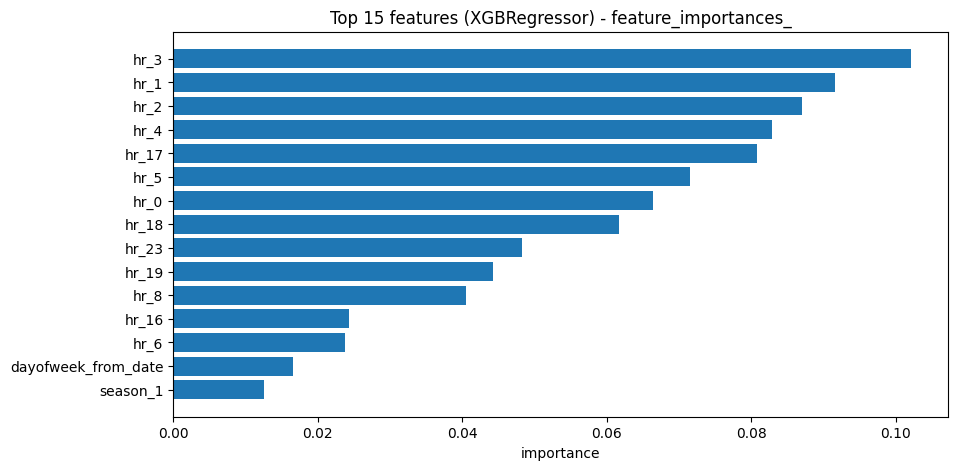

In [16]:

def get_feature_names(preprocess: ColumnTransformer):
    cat_ohe: OneHotEncoder = preprocess.named_transformers_["cat"]
    cat_names = cat_ohe.get_feature_names_out(cat_features)
    num_names = np.array(num_features, dtype=object)
    return np.concatenate([cat_names, num_names])

feature_names = get_feature_names(best_pipe.named_steps["preprocess"])

model = best_pipe.named_steps["model"]

imp = None
imp_type = None

if hasattr(model, "coef_"):
    coef = model.coef_
    imp = np.abs(coef)
    imp_type = "abs(coef)"
elif hasattr(model, "feature_importances_"):
    imp = model.feature_importances_
    imp_type = "feature_importances_"

if imp is None:
    print("이 모델은 중요도/계수 추출을 지원하지 않습니다:", type(model))
else:
    imp_df = pd.DataFrame({"feature": feature_names, "importance": imp}).sort_values("importance", ascending=False)
    display(imp_df.head(15))

    plt.figure(figsize=(10, 5))
    top = imp_df.head(15)[::-1]
    plt.barh(top["feature"], top["importance"])
    plt.title(f"Top 15 features ({best_name}) - {imp_type}")
    plt.xlabel("importance")
    plt.show()
